INPUT
<xarray.DataArray 'wbgt' (valid_time: 744, latitude: 96, longitude: 105)> Size: 30MB
[7499520 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
Attributes:
    units:      degrees_Celsius
    long_name:  Wet-bulb globe temperature
Shape: (744, 96, 105)
Dims: ('valid_time', 'latitude', 'longitude')

OUTPUT
<xarray.DataArray 'wbgt' (valid_time: 744, y: 961, x: 1040)> Size: 3GB
[743583360 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-31T23:...
  * y           (y) float64 8kB 42.06 42.05 42.04 42.03 ... 32.48 32.47 32.46
  * x           (x) float64 8kB -124.4 -124.4 -124.4 ... -114.1 -114.1 -114.1
Attributes:
    long_name:     Wet-bulb globe temperature
    grid_mapping:  crs
    units:       

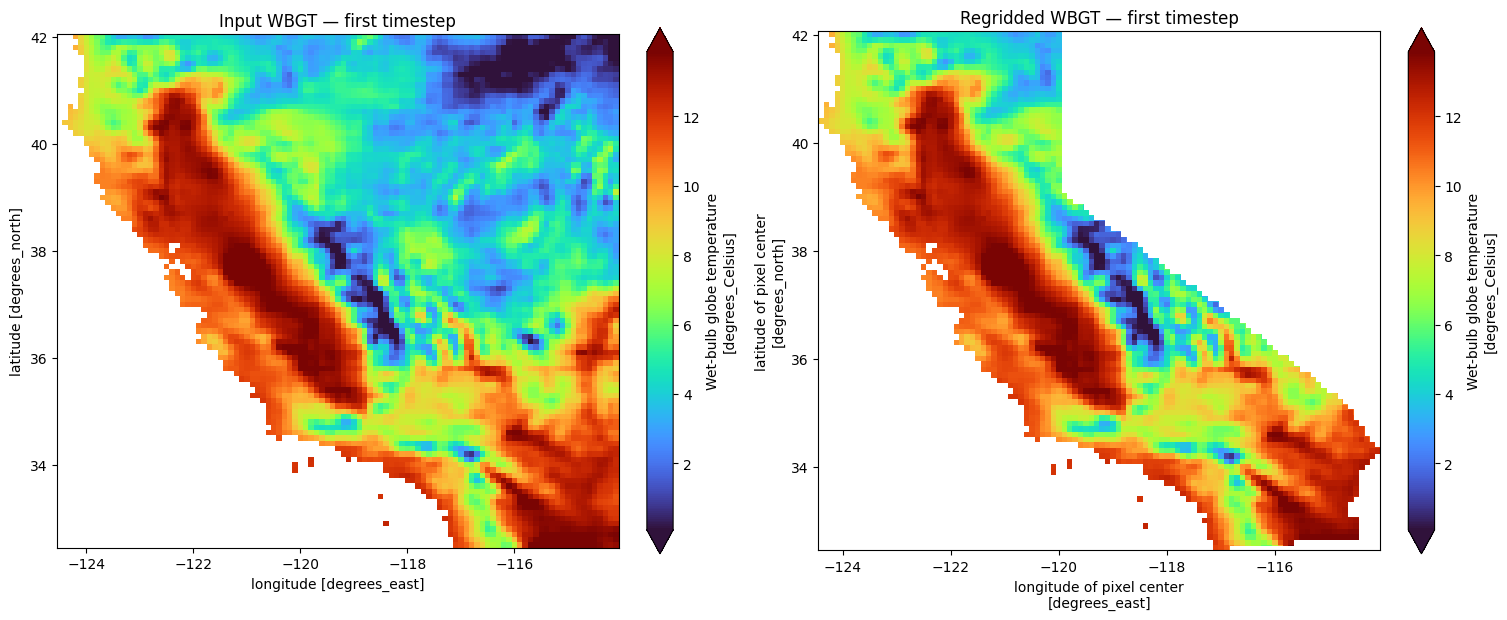

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Files to compare
# ------------------------------------------------------------
input_file = Path(
    r"C:/Users/new account/Desktop/regrid_wbgt/wbgt/wbgt_2000_01.nc"
)

output_file = Path(
    r"C:/Users/new account/Desktop/regrid_wbgt/wbgt_regridded/wbgt_2000_01_regridded.nc"
)

# ------------------------------------------------------------
# Read input
# ------------------------------------------------------------
ds_in = xr.open_dataset(input_file)
da_in = ds_in["wbgt"]

print("INPUT")
print(da_in)
print("Shape:", da_in.shape)
print("Dims:", da_in.dims)

# Pick first timestep if monthly file is hourly
if "valid_time" in da_in.dims:
    input_plot = da_in.isel(valid_time=0)
elif "time" in da_in.dims:
    input_plot = da_in.isel(time=0)
else:
    input_plot = da_in

# ------------------------------------------------------------
# Read output
# ------------------------------------------------------------
ds_out = xr.open_dataset(output_file)
da_out = ds_out["wbgt"]

print("\nOUTPUT")
print(da_out)
print("Shape:", da_out.shape)
print("Dims:", da_out.dims)

output_plot = da_out.isel(valid_time=0)

# ------------------------------------------------------------
# Common color scale
# ------------------------------------------------------------
vmin = np.nanpercentile(input_plot.values, 2)
vmax = np.nanpercentile(input_plot.values, 98)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 6),
    constrained_layout=True
)

input_plot.plot(
    ax=axes[0],
    cmap="turbo",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,
)

axes[0].set_title("Input WBGT — first timestep")
axes[0].set_aspect("equal")

output_plot.plot(
    ax=axes[1],
    cmap="turbo",
    vmin=vmin,
    vmax=vmax,
    add_colorbar=True,
)

axes[1].set_title("Regridded WBGT — first timestep")
axes[1].set_aspect("equal")

plt.show()


In [2]:
import rasterio
import xarray as xr
import numpy as np

master_file = r"C:/Users/new account/Desktop/regrid_wbgt/ERA5_Land_grid0pnt01_CAfull.tif"
output_file = r"C:/Users/new account/Desktop/regrid_wbgt/wbgt_regridded/wbgt_2000_01_regridded.nc"

with rasterio.open(master_file) as src:
    print("MASTER TIF")
    print("width :", src.width)
    print("height:", src.height)
    print("CRS   :", src.crs)
    print("transform:", src.transform)

    master_x = src.transform.c + (
        np.arange(src.width) + 0.5
    ) * src.transform.a

    master_y = src.transform.f + (
        np.arange(src.height) + 0.5
    ) * src.transform.e

ds = xr.open_dataset(output_file)

print("\nOUTPUT NETCDF")
print("x:", ds.sizes["x"])
print("y:", ds.sizes["y"])
print("CRS:", ds["crs"].attrs.get("spatial_ref"))

print("\nGRID CHECK")
print("Same width :", len(master_x) == ds.sizes["x"])
print("Same height:", len(master_y) == ds.sizes["y"])

print(
    "X coordinates identical:",
    np.allclose(master_x, ds["x"].values)
)

print(
    "Y coordinates identical:",
    np.allclose(master_y, ds["y"].values)
)


MASTER TIF
width : 1040
height: 961
CRS   : EPSG:4269
transform: | 0.01, 0.00,-124.45|
| 0.00,-0.01, 42.06|
| 0.00, 0.00, 1.00|

OUTPUT NETCDF
x: 1040
y: 961
CRS: GEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENGTHUNIT["metre",1]]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4269]]

GRID CHECK
Same width : True
Same height: True
X coordinates identical: True
Y coordinates identical: True


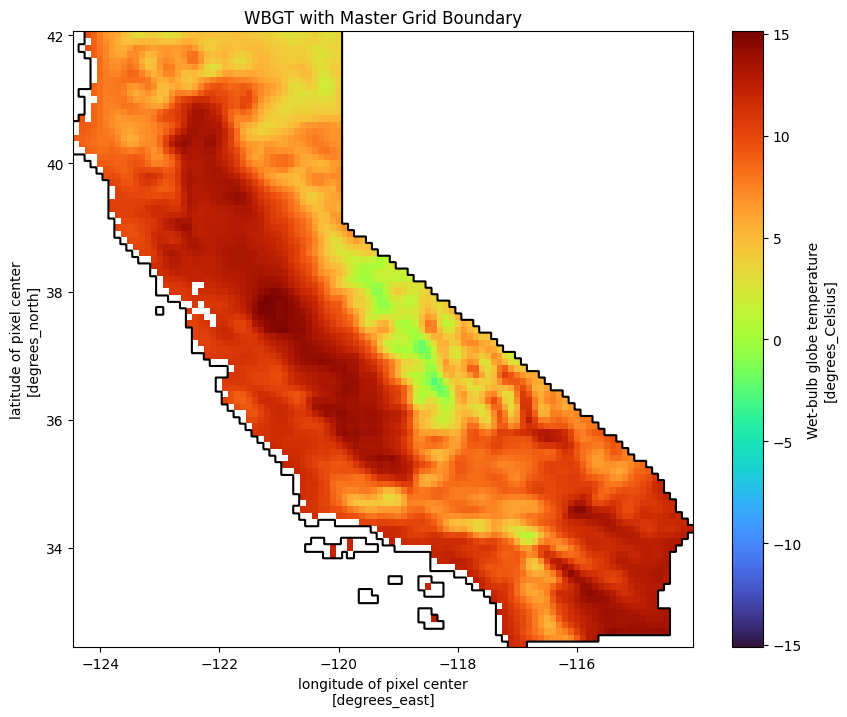

In [3]:
import rasterio
import xarray as xr
import matplotlib.pyplot as plt

master_file = r"C:/Users/new account/Desktop/regrid_wbgt/ERA5_Land_grid0pnt01_CAfull.tif"
output_file = r"C:/Users/new account/Desktop/regrid_wbgt/wbgt_regridded/wbgt_2000_01_regridded.nc"

with rasterio.open(master_file) as src:
    master_mask = src.dataset_mask() > 0

    master_x = (
        src.transform.c
        + (np.arange(src.width) + 0.5) * src.transform.a
    )

    master_y = (
        src.transform.f
        + (np.arange(src.height) + 0.5) * src.transform.e
    )

ds = xr.open_dataset(output_file)
wbgt = ds["wbgt"].isel(valid_time=0)
fig, ax = plt.subplots(figsize=(10, 8))

# WBGT
wbgt.plot(
    ax=ax,
    cmap="turbo",
    add_colorbar=True,
)

# Master mask using the SAME x/y coordinates
ax.contour(
    master_x,
    master_y,
    master_mask.astype(float),
    levels=[0.5],
    colors="black",
    linewidths=1.5,
)

ax.set_title("WBGT with Master Grid Boundary")
plt.show()


In [4]:
from pathlib import Path
import numpy as np
import xarray as xr
import rasterio

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
input_file = Path(
    r"C:/Users/new account/Desktop/regrid_wbgt/wbgt/wbgt_2000_01.nc"
)

output_file = Path(
    r"C:/Users/new account/Desktop/regrid_wbgt/wbgt_regridded/wbgt_2000_01_regridded.nc"
)

master_file = Path(
    r"C:/Users/new account/Desktop/regrid_wbgt/ERA5_Land_grid0pnt01_CAfull.tif"
)


# ============================================================
# INPUT NETCDF
# ============================================================
ds_in = xr.open_dataset(input_file)

# Find horizontal coordinates
if "lon" in ds_in.coords and "lat" in ds_in.coords:
    x_in = ds_in["lon"].values
    y_in = ds_in["lat"].values
    x_name_in = "lon"
    y_name_in = "lat"

elif "longitude" in ds_in.coords and "latitude" in ds_in.coords:
    x_in = ds_in["longitude"].values
    y_in = ds_in["latitude"].values
    x_name_in = "longitude"
    y_name_in = "latitude"

elif "x" in ds_in.coords and "y" in ds_in.coords:
    x_in = ds_in["x"].values
    y_in = ds_in["y"].values
    x_name_in = "x"
    y_name_in = "y"

else:
    raise ValueError("Could not find input x/y or lon/lat coordinates.")


dx_in = np.median(np.abs(np.diff(x_in)))
dy_in = np.median(np.abs(np.diff(y_in)))


# ============================================================
# OUTPUT NETCDF
# ============================================================
ds_out = xr.open_dataset(output_file)

x_out = ds_out["x"].values
y_out = ds_out["y"].values

dx_out = np.median(np.abs(np.diff(x_out)))
dy_out = np.median(np.abs(np.diff(y_out)))


# ============================================================
# MASTER GEOTIFF
# ============================================================
with rasterio.open(master_file) as src:

    dx_master = abs(src.transform.a)
    dy_master = abs(src.transform.e)

    width_master = src.width
    height_master = src.height

    crs_master = src.crs


# ============================================================
# PRINT RESULTS
# ============================================================
print("=" * 60)
print("INPUT WBGT NETCDF")
print("=" * 60)

print(f"Coordinate names : {x_name_in}, {y_name_in}")
print(f"Number of X cells: {len(x_in)}")
print(f"Number of Y cells: {len(y_in)}")
print(f"X resolution     : {dx_in}")
print(f"Y resolution     : {dy_in}")

if x_name_in in ["lon", "longitude"]:
    print(f"X resolution     : {dx_in:.6f} degrees")
    print(f"Y resolution     : {dy_in:.6f} degrees")


print("\n" + "=" * 60)
print("MASTER GEOTIFF")
print("=" * 60)

print(f"Width            : {width_master}")
print(f"Height           : {height_master}")
print(f"X resolution     : {dx_master}")
print(f"Y resolution     : {dy_master}")
print(f"CRS              : {crs_master}")

if crs_master.is_geographic:
    print(f"X resolution     : {dx_master:.6f} degrees")
    print(f"Y resolution     : {dy_master:.6f} degrees")


print("\n" + "=" * 60)
print("OUTPUT NETCDF")
print("=" * 60)

print(f"Number of X cells: {len(x_out)}")
print(f"Number of Y cells: {len(y_out)}")
print(f"X resolution     : {dx_out}")
print(f"Y resolution     : {dy_out}")
print(f"CRS              : {ds_out['crs'].attrs.get('crs_wkt', 'not found')[:100]}...")


print("\n" + "=" * 60)
print("RESOLUTION CHECK")
print("=" * 60)

print(
    f"Input X ≈ Master X: "
    f"{np.isclose(dx_in, dx_master)}"
)

print(
    f"Input Y ≈ Master Y: "
    f"{np.isclose(dy_in, dy_master)}"
)

print(
    f"Output X = Master X: "
    f"{np.isclose(dx_out, dx_master)}"
)

print(
    f"Output Y = Master Y: "
    f"{np.isclose(dy_out, dy_master)}"
)


INPUT WBGT NETCDF
Coordinate names : longitude, latitude
Number of X cells: 105
Number of Y cells: 96
X resolution     : 0.09999999999999432
Y resolution     : 0.10000000000000142
X resolution     : 0.100000 degrees
Y resolution     : 0.100000 degrees

MASTER GEOTIFF
Width            : 1040
Height           : 961
X resolution     : 0.01
Y resolution     : 0.01
CRS              : EPSG:4269
X resolution     : 0.010000 degrees
Y resolution     : 0.010000 degrees

OUTPUT NETCDF
Number of X cells: 1040
Number of Y cells: 961
X resolution     : 0.010000000000005116
Y resolution     : 0.00999999999999801
CRS              : GEOGCRS["NAD83",DATUM["North American Datum 1983",ELLIPSOID["GRS 1980",6378137,298.257222101004,LENG...

RESOLUTION CHECK
Input X ≈ Master X: False
Input Y ≈ Master Y: False
Output X = Master X: True
Output Y = Master Y: True
